In [7]:
import pandas as pd
import xarray as xr
import numpy as np
import sklearn as sk



In [8]:

import os, time, json
from contextlib import contextmanager
import numpy as np

# ---------------- CONFIG ----------------
LOSS_NAME = "grad"          # <-- change this per run
LOSS_KW = {}               # per-loss knobs, e.g. {"delta": 1.0} for huber
                           #   huber   : delta (default 1.0)
                           #   wmse    : power (default 1.0)
                           #   tail    : alpha (default 1.0), power (default 1.0)
                           #   pinball : tau (default 0.5)
                           #   grad    : w_grad (default 1.0)
                           #   spectral: w_spec (default 1.0)

IMD_TARGET_VAR = "rain"
WINDOWS = [("week2", 8, 14), ("week3_4", 15, 28), ("week5_6", 29, 42)]
CLIM_WINDOW_DAYS = 7
COARSE_PAD = 3.0
MONTHS = None
TEST_YEARS_N = 3
CACHE = "../data/cache/unet_cache_mw.npz"
DTYPE = np.float32

class Args:
    cmd = "train"
    k_coarse = 5          # "prepare" or "train"
    epochs = 60
    batch = 4
    base = 24
    drop = 0.2
    wd = 1e-3
    lr = 2e-5
    patience = 10
    folds = 5

args = Args()
ARG_DICT = {k: getattr(args, k) for k in dir(args) if not k.startswith("_")}
ARG_DICT["loss"] = LOSS_NAME
ARG_DICT["loss_kw"] = LOSS_KW

# separate outputs per loss so runs never collide or resume each other
tag = LOSS_NAME + ("_" + "_".join(f"{k}{v}" for k, v in LOSS_KW.items()) if LOSS_KW else "")
OUT_MAPS = f"../results/models/unet_mw_{tag}.nc"


@contextmanager
def stage(name):
    print(f"[ ] {name} ...", flush=True)
    t0 = time.perf_counter()
    yield
    print(f"[x] {name}  ({time.perf_counter() - t0:.1f}s)", flush=True)



In [10]:
#  ======================================================================
# PREPARE
# ======================================================================

def normalize_step(ds, verbose=True):
    v = ds["step"].values
    if np.issubdtype(v.dtype, np.timedelta64):
        return ds
    mx = int(np.nanmax(v))
    u = "D" if mx <= 60 else ("h" if mx <= 24 * 60 else "s")
    if verbose:
        print(f"    step is {v.dtype} (max {mx}) -> units='{u}'")
    td = v.astype(np.int64).astype(f"timedelta64[{u}]").astype("timedelta64[ns]")
    return ds.assign_coords(step=("step", td))


def ensure_valid_time(ds):
    ds = normalize_step(ds)
    expected = ds["time"] + ds["step"]
    if "valid_time" in ds.coords:
        got = ds["valid_time"]
        if got.shape == expected.shape and (got.values == expected.values).all():
            return ds
        print("    WARNING: existing valid_time != time + step -> rebuilding")
        ds = ds.drop_vars("valid_time")
    return ds.assign_coords(valid_time=expected)


def _doy_matrix(doys, window, n_doy=366):
    centers = np.arange(1, n_doy + 1)
    d = np.abs(doys[None, :].astype(int) - centers[:, None])
    return (np.minimum(d, n_doy - d) <= window).astype(DTYPE)


def _clim_grid(values, doys, window):
    shp = values.shape[1:]
    v2 = values.reshape(len(values), -1)
    M = _doy_matrix(doys, window)
    counts = M @ np.isfinite(v2).astype(DTYPE)
    sums = M @ np.nan_to_num(v2).astype(DTYPE)
    with np.errstate(invalid="ignore", divide="ignore"):
        clim = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
    return clim.reshape((366,) + shp).astype(DTYPE)


def prepare(ecmwf_ds, imd_ds, cache_path):
    import xarray as xr
    from dask.diagnostics import ProgressBar

    with stage("Coarse subset over padded India box"):
        ecmwf_ds = ensure_valid_time(ecmwf_ds)
        for c in ("lat", "lon"):
            if ecmwf_ds[c].values[0] > ecmwf_ds[c].values[-1]:
                ecmwf_ds = ecmwf_ds.sortby(c)
        la0, la1 = float(imd_ds.lat.min()), float(imd_ds.lat.max())
        lo0, lo1 = float(imd_ds.lon.min()), float(imd_ds.lon.max())
        sub = ecmwf_ds.sel(lat=slice(la0 - COARSE_PAD, la1 + COARSE_PAD),
                           lon=slice(lo0 - COARSE_PAD, lo1 + COARSE_PAD))
        if MONTHS is not None:
            sub = sub.sel(time=sub["time"].dt.month.isin(list(MONTHS)))
        feature_vars = list(sub.data_vars)
        clat, clon = sub["lat"].values, sub["lon"].values
        leads = (sub["step"].values / np.timedelta64(1, "D")).astype(int)
        init = sub["time"].values
        print(f"    {dict(sub.sizes)} x {len(feature_vars)} vars")

    imd = imd_ds[IMD_TARGET_VAR]
    imd = imd.assign_coords(time=imd["time"].dt.floor("D"))
    flat_lat, flat_lon = imd["lat"].values, imd["lon"].values

    X_list, y_list, doy_list, wid_list = [], [], [], []
    for wid, (wname, lo, hi) in enumerate(WINDOWS):
        with stage(f"Window {wname} (days {lo}-{hi})"):
            sel = np.where((leads >= lo) & (leads <= hi))[0]
            if len(sel) == 0:
                raise ValueError(f"no leads in [{lo},{hi}]")
            with ProgressBar():
                Xw = sub.isel(step=sel).mean(dim="step").compute()
            Xa = np.stack([Xw[v].values for v in feature_vars], axis=1).astype(DTYPE)
            vt = sub["valid_time"].isel(step=sel).dt.floor("D").values
            with ProgressBar():
                y_all = imd.reindex(time=vt.ravel()).astype(DTYPE).compute().values
            ya = np.nanmean(y_all.reshape(vt.shape + y_all.shape[1:]), axis=1)
            centre = init + np.timedelta64((lo + hi) // 2, "D")
            doya = xr.DataArray(centre, dims="t").dt.dayofyear.values
            X_list.append(Xa); y_list.append(ya)
            doy_list.append(doya); wid_list.append(np.full(len(Xa), wid, dtype=np.int64))
            print(f"    +{len(Xa)} samples")

    X = np.concatenate(X_list); y = np.concatenate(y_list)
    doy = np.concatenate(doy_list); wid = np.concatenate(wid_list)
    year = np.concatenate([init.astype("datetime64[Y]").astype(int) + 1970] * len(WINDOWS))
    print(f"\n    total {len(X)} samples ({len(init)} inits x {len(WINDOWS)} windows)")

    with stage("Strict mask + test-year holdout"):
        mask = np.isfinite(y).all(axis=0)
        print(f"    strict mask: {int(mask.sum())} cells")
        uy = np.unique(year)
        test_years = set(uy[-TEST_YEARS_N:])
        is_test = np.isin(year, list(test_years))
        print(f"    test years: {sorted(test_years)}")

    with stage("Caching"):
        np.savez_compressed(
            cache_path, X=X, y=y, doy=doy, wid=wid, year=year,
            mask=mask, is_test=is_test, clat=clat, clon=clon,
            flat_lat=flat_lat, flat_lon=flat_lon,
            feature_vars=np.array(feature_vars),
            window_names=np.array([w[0] for w in WINDOWS]))
        print(f"    {os.path.getsize(cache_path)/1e9:.2f} GB -> {cache_path}")


def anomalise_fold(X, y, doy, tr):
    """Train-fold-only climatology + standardisation. Leakage-critical."""
    clim_y = _clim_grid(y[tr], doy[tr], CLIM_WINDOW_DAYS)
    clim_X = _clim_grid(X[tr], doy[tr], CLIM_WINDOW_DAYS)
    ya = y - clim_y[doy - 1]
    Xa = X - clim_X[doy - 1]
    xm = np.nanmean(Xa[tr], axis=(0, 2, 3), keepdims=True)
    xs = np.nanstd(Xa[tr], axis=(0, 2, 3), keepdims=True)
    xs = np.where(xs < 1e-8, 1.0, xs)
    Xa = np.nan_to_num((Xa - xm) / xs)
    return Xa.astype(DTYPE), ya.astype(DTYPE), clim_y

def precompute_year_partials(X, y, doy, year, window):
    """One-time cost: per-year DOY-weighted sums & counts for X and y."""
    X_flat = X.reshape(len(X), -1)
    y_flat = y.reshape(len(y), -1)
    partials = {}
    for yr in np.unique(year):
        idx = year == yr
        M = _doy_matrix(doy[idx], window)          # (366, n_yr)
        xv, yv = X_flat[idx], y_flat[idx]
        partials[int(yr)] = (
            M @ np.nan_to_num(xv).astype(DTYPE),   # x_sums   (366, px_x)
            M @ np.isfinite(xv).astype(DTYPE),      # x_counts
            M @ np.nan_to_num(yv).astype(DTYPE),    # y_sums   (366, px_y)
            M @ np.isfinite(yv).astype(DTYPE),      # y_counts
        )
    return partials


def anomalise_fold_fast(X, y, doy, tr_mask, year, partials):
    """Same as anomalise_fold but assembles climatology from precomputed partials."""
    tr_years = set(year[tr_mask].tolist())

    # combine training-year partials by simple addition
    xs = xc = ys = yc = None
    for yr in tr_years:
        pxs, pxc, pys, pyc = partials[yr]
        if xs is None:
            xs, xc, ys, yc = pxs.copy(), pxc.copy(), pys.copy(), pyc.copy()
        else:
            xs += pxs; xc += pxc; ys += pys; yc += pyc

    with np.errstate(invalid="ignore", divide="ignore"):
        clim_X = np.where(xc > 0, xs / np.maximum(xc, 1), np.nan)
        clim_y = np.where(yc > 0, ys / np.maximum(yc, 1), np.nan)
    clim_X = clim_X.reshape((366,) + X.shape[1:]).astype(DTYPE)
    clim_y = clim_y.reshape((366,) + y.shape[1:]).astype(DTYPE)

    ya = y - clim_y[doy - 1]
    Xa = X - clim_X[doy - 1]
    xm = np.nanmean(Xa[tr_mask], axis=(0, 2, 3), keepdims=True)
    xs2 = np.nanstd(Xa[tr_mask], axis=(0, 2, 3), keepdims=True)
    xs2 = np.where(xs2 < 1e-8, 1.0, xs2)
    Xa = np.nan_to_num((Xa - xm) / xs2)
    return Xa.astype(DTYPE), ya.astype(DTYPE), clim_y



# ======================================================================
# LOSS FAMILY
# ======================================================================

def make_loss(name, target_std, **kw):
    """Return fn(pred, target, mask) -> scalar. All masked, all normalised
    by mask.sum() (never numel), all operating on anomalies.

    target_std: scalar float, train-set anomaly std. Used to make the
    intensity-weighted variants scale-free so their knobs mean the same
    thing regardless of units.
    """
    import torch
    import torch.nn.functional as F

    def _m(x, m):
        """mask, sum, normalise by mask -- the one correct reduction."""
        return (x * m).sum() / m.sum().clamp(min=1.0)

    if name == "mse":
        def f(p, t, m):
            return _m((p - t) ** 2, m)

    elif name == "mae":
        def f(p, t, m):
            return _m((p - t).abs(), m)

    elif name == "huber":
        delta = kw.get("delta", 1.0)
        def f(p, t, m):
            e = (p - t).abs()
            q = torch.clamp(e, max=delta)
            return _m(0.5 * q ** 2 + delta * (e - q), m)

    elif name == "logcosh":
        def f(p, t, m):
            e = p - t
            # numerically stable log(cosh(e))
            return _m(e + F.softplus(-2.0 * e) - float(np.log(2.0)), m) \
                if False else _m(torch.log(torch.cosh(torch.clamp(e, -12, 12))), m)

    elif name == "wmse":
        # intensity-weighted MSE: weight each cell by how extreme the OBS is.
        # This is the Chandel-style "weighted loss for extremes" idea.
        power = kw.get("power", 1.0)
        def f(p, t, m):
            w = 1.0 + (t.abs() / target_std) ** power
            return _m(w * (p - t) ** 2, m)

    elif name == "tail":
        # like wmse but with an explicit strength knob; alpha=0 -> plain MSE
        alpha = kw.get("alpha", 1.0)
        power = kw.get("power", 1.0)
        def f(p, t, m):
            w = (1.0 + alpha * (t.abs() / target_std)) ** power
            return _m(w * (p - t) ** 2, m)

    elif name == "pinball":
        # asymmetric: under-prediction costs tau/(1-tau) more than over.
        # tau=0.5 == MAE/2. tau>0.5 pushes predictions UP (anti-hedge for wet).
        tau = kw.get("tau", 0.5)
        def f(p, t, m):
            e = t - p
            return _m(torch.maximum(tau * e, (tau - 1.0) * e), m)

    elif name == "grad":
        # MSE + spatial-gradient matching. Scores STRUCTURE, not per-cell
        # amplitude, so it has a mechanism the pointwise family lacks.
        wg = kw.get("w_grad", 1.0)
        def f(p, t, m):
            base = _m((p - t) ** 2, m)
            mx = m[:, :, 1:] * m[:, :, :-1]
            my = m[:, 1:, :] * m[:, :-1, :]
            gx = ((p[:, :, 1:] - p[:, :, :-1]) - (t[:, :, 1:] - t[:, :, :-1])) ** 2
            gy = ((p[:, 1:, :] - p[:, :-1, :]) - (t[:, 1:, :] - t[:, :-1, :])) ** 2
            return base + wg * (_m(gx, mx) + _m(gy, my))

    elif name == "spectral":
        # MSE + radially-averaged power spectrum matching. Directly targets
        # the "deterministic nets lose power at fine scales" problem.
        ws = kw.get("w_spec", 1.0)
        def f(p, t, m):
            base = _m((p - t) ** 2, m)
            pf = torch.fft.rfft2(p * m)
            tf = torch.fft.rfft2(t * m)
            pp = (pf.real ** 2 + pf.imag ** 2 + 1e-8).mean(dim=0)
            tp = (tf.real ** 2 + tf.imag ** 2 + 1e-8).mean(dim=0)
            return base + ws * (torch.log(pp) - torch.log(tp)).abs().mean()

    else:
        raise ValueError(f"unknown LOSS_NAME '{name}'")

    return f

In [ ]:
# ======================================================================
# MODEL + TRAIN
# ======================================================================
args.cmd = "train"

def build_and_run(args, cache_path, out_maps, loss_name, loss_kw):
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, TensorDataset

    dev = ("cuda" if torch.cuda.is_available()
           else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"    device: {dev} | loss: {loss_name} {loss_kw}")

    z = np.load(cache_path, allow_pickle=False)
    X, y, doy, wid = z["X"], z["y"], z["doy"], z["wid"]
    year, mask, is_test = z["year"], z["mask"], z["is_test"]
    clat, clon = z["clat"], z["clon"]
    flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
    n_win = len(z["window_names"]); H, W = len(flat_lat), len(flat_lon)
    n_var = X.shape[1]

    gy = 2 * (flat_lat - clat[0]) / (clat[-1] - clat[0]) - 1
    gx = 2 * (flat_lon - clon[0]) / (clon[-1] - clon[0]) - 1
    gyy, gxx = np.meshgrid(gy, gx, indexing="ij")
    samp_np = np.stack([gxx, gyy], -1).astype(np.float32)[None]
    assert np.abs(samp_np).max() <= 1.0, "fine grid outside coarse box"

    lat2 = (flat_lat[:, None] - flat_lat.mean()) / flat_lat.std()
    lon2 = (flat_lon[None, :] - flat_lon.mean()) / flat_lon.std()
    static_np = np.stack([mask.astype(DTYPE),
                          np.broadcast_to(lat2, (H, W)).astype(DTYPE),
                          np.broadcast_to(lon2, (H, W)).astype(DTYPE)])[None]

    def gn(c):
        for g in (8, 4, 2, 1):
            if c % g == 0:
                return nn.GroupNorm(g, c)

    class Block(nn.Module):
        def __init__(self, ci, co, drop=0.0,k=3):
            super().__init__()
            p = k // 2
            L = [nn.Conv2d(ci, co, k, padding=p), gn(co), nn.SiLU(),
                 nn.Conv2d(co, co, k, padding=p), gn(co), nn.SiLU()]
            if drop > 0:
                L.append(nn.Dropout2d(drop))
            self.f = nn.Sequential(*L)
        def forward(self, x):
            return self.f(x)

    class MWUNet(nn.Module):
        def __init__(self, n_var, n_win, base=24, drop=0.2, emb=4):
            super().__init__()
            self.emb = nn.Embedding(n_win, emb)
            self.enc_c1 = Block(n_var + emb, base * 2, k = args.k_coarse)
            self.enc_c2 = Block(base * 2, base * 2, k= args.k_coarse)
            self.inp = Block(base * 2 + 3, base)
            self.d1 = Block(base, base * 2, drop)
            self.d2 = Block(base * 2, base * 4, drop)
            self.bott = Block(base * 4, base * 4, drop)
            self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
            self.du2 = Block(base * 4, base * 2, drop)
            self.u1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
            self.du1 = Block(base * 2, base)
            self.head = nn.Conv2d(base, 1, 1)
            self.pool = nn.MaxPool2d(2)
        def forward(self, xc, wid, samp, static):
            b, _, h, w = xc.shape
            e = self.emb(wid)[:, :, None, None].expand(-1, -1, h, w)
            c = self.enc_c2(self.enc_c1(torch.cat([xc, e], 1)))
            f = F.grid_sample(c, samp.expand(b, -1, -1, -1),
                              mode="bilinear", align_corners=True)
            f = torch.cat([f, static.expand(b, -1, -1, -1)], 1)
            H0, W0 = f.shape[-2:]
            f = F.pad(f, (0, (-W0) % 4, 0, (-H0) % 4), mode="replicate")
            e0 = self.inp(f); e1 = self.d1(self.pool(e0)); e2 = self.d2(self.pool(e1))
            u = self.du2(torch.cat([self.u2(self.bott(e2)), e1], 1))
            u = self.du1(torch.cat([self.u1(u), e0], 1))
            return self.head(u)[:, :, :H0, :W0].squeeze(1)

    samp = torch.tensor(samp_np).to(dev)
    stat = torch.tensor(static_np).to(dev)

    def skill_acc(p, t, fin):
        se_m = np.where(fin, (t - p) ** 2, np.nan)
        se_c = np.where(fin, t ** 2, np.nan)
        with np.errstate(invalid="ignore"):
            rmse_m = np.sqrt(np.nanmean(se_m, axis=0))
            rmse_c = np.sqrt(np.nanmean(se_c, axis=0))
            ok = rmse_c > 1e-6
            skill = np.where(ok, 1 - rmse_m / np.where(ok, rmse_c, 1), np.nan)
            tm = np.nanmean(np.where(fin, t, np.nan), axis=0)
            pm = np.nanmean(np.where(fin, p, np.nan), axis=0)
            num = np.nansum(np.where(fin, (t - tm) * (p - pm), np.nan), axis=0)
            den = np.sqrt(np.nansum(np.where(fin, (t - tm) ** 2, np.nan), axis=0)
                          * np.nansum(np.where(fin, (p - pm) ** 2, np.nan), axis=0))
            acc = np.where(den > 0, num / den, np.nan)
        return skill, acc

    def std_ratio(p, t, fin):
        """Diagnostic only -- reported, never optimised."""
        pv, tv = p[fin], t[fin]
        return float(pv.std() / tv.std()) if tv.std() > 0 else np.nan

    def train_one(tr_idx, va_idx, Xa, ya, max_epochs):
        Xt = torch.tensor(Xa)
        yt = torch.tensor(np.nan_to_num(ya))
        widt = torch.tensor(wid)
        fin = torch.tensor((np.isfinite(ya) & mask[None]).astype(DTYPE))

        tstd = float(np.nanstd(ya[tr_idx][np.isfinite(ya[tr_idx])]))
        crit = make_loss(loss_name, tstd, **loss_kw)

        def dl(idx, sh):
            return DataLoader(TensorDataset(Xt[idx], widt[idx], yt[idx], fin[idx]),
                              batch_size=args.batch, shuffle=sh)

        tr_dl, va_dl = dl(tr_idx, True), dl(va_idx, False)
        model = MWUNet(n_var, n_win, base=args.base, drop=args.drop).to(dev)
        opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.wd)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)

        best, best_state, wait = np.inf, None, 0
        for ep in range(max_epochs):
            model.train()
            for xb, wb, yb, mb in tr_dl:
                xb, wb, yb, mb = [t.to(dev) for t in (xb, wb, yb, mb)]
                loss = crit(model(xb, wb, samp, stat), yb, mb)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()
            sched.step()

            model.eval()
            vl, n = 0.0, 0
            with torch.no_grad():
                for xb, wb, yb, mb in va_dl:
                    xb, wb, yb, mb = [t.to(dev) for t in (xb, wb, yb, mb)]
                    vl += float(crit(model(xb, wb, samp, stat), yb, mb)) * len(xb)
                    n += len(xb)
            vl /= n
            if vl < best - 1e-6:
                best, wait = vl, 0
                best_state = {k: v.detach().cpu().clone()
                              for k, v in model.state_dict().items()}
            else:
                wait += 1
            if wait >= args.patience:
                break
        model.load_state_dict(best_state)
        return model, best, ep + 1

    def predict(model, idx, Xa):
        Xt = torch.tensor(Xa); widt = torch.tensor(wid)
        out = []
        model.eval()
        with torch.no_grad():
            for a in range(0, len(idx), args.batch):
                j = idx[a:a + args.batch]
                out.append(model(Xt[j].to(dev), widt[j].to(dev), samp, stat).cpu().numpy())
        return np.concatenate(out)

    with stage("Precomputing per-year climatology partials"):
        partials = precompute_year_partials(X, y, doy, year, CLIM_WINDOW_DAYS)


    # ---------- rotating-year CV ----------
    nontest_years = sorted(set(year[~is_test].tolist()))
    blocks = np.array_split(nontest_years, args.folds)
    resume_path = out_maps.replace(".nc", "_folds.json")
    done = {}
    if os.path.exists(resume_path):
        with open(resume_path) as fh:
            done = {int(k): v for k, v in json.load(fh).items()}
        print(f"    resuming: folds {sorted(done)} cached ({resume_path})")

    with stage(f"Rotating-year CV: {args.folds} folds over {len(nontest_years)} years"):
        for fi, val_years in enumerate(blocks):
            if fi in done:
                r = done[fi]
                print(f"    fold {fi} (cached): skill {r['skill']:+.3f} | ACC {r['acc']:.3f}")
                continue
            val_years = set(val_years.tolist())
            va_i = np.isin(year, list(val_years)) & ~is_test
            tr_i = ~np.isin(year, list(val_years)) & ~is_test
            Xa, ya, _ = anomalise_fold_fast(X, y, doy, tr_i, year, partials)

            model, vloss, eps = train_one(np.where(tr_i)[0], np.where(va_i)[0],
                                          Xa, ya, args.epochs)
            p = predict(model, np.where(va_i)[0], Xa)
            np.savez_compressed(out_maps.replace(".nc", "_pred.npz"),
                    pred=p, obs=t, wid=wid[is_test])
            t = ya[va_i]
            fin = np.isfinite(y[va_i]) & mask[None]
            sk, ac = skill_acc(p, t, fin)
            ms, ma = float(np.nanmean(sk[mask])), float(np.nanmean(ac[mask]))
            sr = std_ratio(p, t, fin)
            done[fi] = {"skill": ms, "acc": ma, "std_ratio": sr,
                        "val_years": sorted(val_years), "epochs": int(eps),
                        "vloss": float(vloss)}
            with open(resume_path, "w") as fh:
                json.dump({str(k): v for k, v in done.items()}, fh, indent=2)
            print(f"    fold {fi} val {sorted(val_years)}: skill {ms:+.3f} | "
                  f"ACC {ma:.3f} | std_ratio {sr:.3f} | {eps} ep   [saved]", flush=True)

        ks = [i for i in range(args.folds) if i in done]
        fs = [done[i]["skill"] for i in ks]; fa = [done[i]["acc"] for i in ks]
        fr = [done[i].get("std_ratio", np.nan) for i in ks]
        print(f"\n    [{loss_name}]  CV skill {np.mean(fs):+.4f} +/- {np.std(fs):.4f}"
              f" | CV ACC {np.mean(fa):.4f} +/- {np.std(fa):.4f}"
              f" | std_ratio {np.nanmean(fr):.3f}")

    # ---------- final model -> test ----------
    with stage("Final model on all non-test years -> test"):
        es_years = set(nontest_years[-2:])
        va_i = np.isin(year, list(es_years)) & ~is_test
        fit_i = (~is_test) & ~va_i
        Xa, ya, _ = anomalise_fold_fast(X, y, doy, fit_i, year, partials)
        model, _, eps = train_one(np.where(fit_i)[0], np.where(va_i)[0], Xa, ya, args.epochs)

        te_i = np.where(is_test)[0]
        p = predict(model, te_i, Xa)
        t = ya[is_test]
        fin = np.isfinite(y[is_test]) & mask[None]

        import xarray as xr
        wid_te = wid[is_test]; data_vars = {}
        print(f"    trained {eps} ep")
        summary = {}
        for w in range(n_win):
            sm = wid_te == w
            if sm.sum() == 0:
                continue
            sk, ac = skill_acc(p[sm], t[sm], fin[sm])
            sr = std_ratio(p[sm], t[sm], fin[sm])
            wn = str(z["window_names"][w])
            data_vars[f"{wn}_skill"] = (("lat", "lon"), sk)
            data_vars[f"{wn}_acc"] = (("lat", "lon"), ac)
            summary[wn] = {"skill": float(np.nanmean(sk[mask])),
                           "acc": float(np.nanmean(ac[mask])),
                           "std_ratio": sr,
                           "pct_pos": float(100 * np.nanmean(sk[mask] > 0))}
            print(f"    test {wn:>8}: skill {summary[wn]['skill']:+.4f} | "
                  f"ACC {summary[wn]['acc']:.4f} | std_ratio {sr:.3f} | "
                  f"{summary[wn]['pct_pos']:.0f}% cells+")

        out = xr.Dataset(data_vars, coords={"lat": flat_lat, "lon": flat_lon})
        out.attrs["loss"] = f"{loss_name} {loss_kw}"
        out.attrs["windows"] = ", ".join(f"{n}:{lo}-{hi}" for n, lo, hi in WINDOWS)
        out.to_netcdf(out_maps)
        torch.save({"state": model.state_dict(), "args": ARG_DICT}, out_maps.replace(".nc", ".pt"))

        # append to a cross-loss comparison table
        tbl = "../results/models/loss_comparison.json"
        allr = json.load(open(tbl)) if os.path.exists(tbl) else {}
        allr[tag] = {"cv_skill": float(np.mean(fs)), "cv_acc": float(np.mean(fa)),
                     "cv_std_ratio": float(np.nanmean(fr)), "test": summary}
        json.dump(allr, open(tbl, "w"), indent=2)
        print(f"    -> {out_maps} (+ .pt); comparison appended to {tbl}")


# ======================================================================
if args.cmd == "prepare":
    prepare(ds_ecmv, ds_imd, CACHE)          # noqa: F821
else:
    if not os.path.exists(CACHE):
        raise SystemExit(f"run prepare first ({CACHE} missing)")
    build_and_run(args, CACHE, OUT_MAPS, LOSS_NAME, LOSS_KW)

    # print the running cross-loss comparison
    tbl = "../results/models/loss_comparison.json"
    if os.path.exists(tbl):
        allr = json.load(open(tbl))
        print(f"\n{'loss':>22} {'CV skill':>10} {'CV ACC':>8} {'std':>6} "
              f"{'w3_4 skill':>11} {'w3_4 ACC':>9}")
        for k, v in sorted(allr.items()):
            w = v["test"].get("week3_4", {})
            print(f"{k:>22} {v['cv_skill']:>+10.4f} {v['cv_acc']:>8.4f} "
                  f"{v['cv_std_ratio']:>6.3f} {w.get('skill', float('nan')):>+11.4f} "
                  f"{w.get('acc', float('nan')):>9.4f}")

    device: mps | loss: grad {}
[ ] Precomputing per-year climatology partials ...
[x] Precomputing per-year climatology partials  (1.7s)
[ ] Rotating-year CV: 5 folds over 17 years ...


/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2339/1988421095.py:90: RuntimeWarning: Mean of empty slice
  rmse_m = np.sqrt(np.nanmean(se_m, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2339/1988421095.py:91: RuntimeWarning: Mean of empty slice
  rmse_c = np.sqrt(np.nanmean(se_c, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2339/1988421095.py:94: RuntimeWarning: Mean of empty slice
  tm = np.nanmean(np.where(fin, t, np.nan), axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2339/1988421095.py:95: RuntimeWarning: Mean of empty slice
  pm = np.nanmean(np.where(fin, p, np.nan), axis=0)


    fold 0 val [2005, 2006, 2007, 2008]: skill +0.024 | ACC 0.232 | std_ratio 0.223 | 16 ep   [saved]
    fold 1 val [2009, 2010, 2011, 2012]: skill +0.025 | ACC 0.228 | std_ratio 0.262 | 15 ep   [saved]
    fold 2 val [2013, 2014, 2015]: skill +0.023 | ACC 0.238 | std_ratio 0.282 | 17 ep   [saved]
    fold 3 val [2016, 2017, 2018]: skill +0.029 | ACC 0.248 | std_ratio 0.280 | 17 ep   [saved]
    fold 4 val [2019, 2020, 2021]: skill +0.017 | ACC 0.225 | std_ratio 0.297 | 21 ep   [saved]

    [grad]  CV skill +0.0235 +/- 0.0036 | CV ACC 0.2343 +/- 0.0082 | std_ratio 0.269
[x] Rotating-year CV: 5 folds over 17 years  (9076.2s)
[ ] Final model on all non-test years -> test ...
    trained 14 ep
    test    week2: skill +0.0374 | ACC 0.3179 | std_ratio 0.327 | 83% cells+
    test  week3_4: skill +0.0036 | ACC 0.1598 | std_ratio 0.207 | 63% cells+
    test  week5_6: skill -0.0057 | ACC 0.0625 | std_ratio 0.116 | 50% cells+
    -> unet_mw_grad.nc (+ .pt); comparison appended to loss_comparis

In [14]:
import numpy as np
import torch
import torch.nn.functional as F

def evaluate_baseline(cache_path="../data/cache/unet_cache_mw.npz", clim_window_days=7):
    print("Loading cache and evaluating ECMWF Baseline Skill on Test Set...")
    
    # 1. Load data
    z = np.load(cache_path, allow_pickle=False)
    X, y, doy, wid = z["X"], z["y"], z["doy"], z["wid"]
    mask, is_test = z["mask"], z["is_test"]
    clat, clon = z["clat"], z["clon"]
    flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
    window_names = z["window_names"]
    
    # Recreate the interpolation grid (samp_np)
    gy = 2 * (flat_lat - clat[0]) / (clat[-1] - clat[0]) - 1
    gx = 2 * (flat_lon - clon[0]) / (clon[-1] - clon[0]) - 1
    gyy, gxx = np.meshgrid(gy, gx, indexing="ij")
    samp_np = np.stack([gxx, gyy], -1).astype(np.float32)[None]
    
    # 2. Find precipitation index
    precip_idx = list(z["feature_vars"]).index('total_precipitation')
    
    # 3. Extract precipitation for ALL dates so we can compute climatology
    X_precip = torch.tensor(X[:, precip_idx:precip_idx+1, :, :], dtype=torch.float32)
    
    # 4. Interpolate coarse ECMWF grid to the fine IMD grid (129 x 135)
    samp_tensor = torch.tensor(samp_np).expand(len(X_precip), -1, -1, -1)
    ecmwf_fine = F.grid_sample(
        X_precip, samp_tensor, mode="bilinear", align_corners=True
    ).squeeze(1).numpy()
    
    # Define climatology helper (using numpy directly instead of your custom _clim_grid for independence)
    def _clim(values, doys, window=clim_window_days, n_doy=366):
        shp = values.shape[1:]
        v2 = values.reshape(len(values), -1)
        centers = np.arange(1, n_doy + 1)
        d = np.abs(doys[None, :].astype(int) - centers[:, None])
        M = (np.minimum(d, n_doy - d) <= window).astype(np.float32)
        counts = M @ np.isfinite(v2).astype(np.float32)
        sums = M @ np.nan_to_num(v2).astype(np.float32)
        with np.errstate(invalid="ignore", divide="ignore"):
            c = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
        return c.reshape((n_doy,) + shp).astype(np.float32)
        
    # 5. Compute training-only climatologies (to prevent leakage)
    tr_i = ~is_test
    clim_ecmwf = _clim(ecmwf_fine[tr_i], doy[tr_i])
    clim_y = _clim(y[tr_i], doy[tr_i])
    
    # 6. Calculate anomalies for the test set
    te_i = np.where(is_test)[0]
    p_baseline = ecmwf_fine[te_i] - clim_ecmwf[doy[te_i] - 1]  
    t_target = y[te_i] - clim_y[doy[te_i] - 1]                 
    
    # Recreate the skill_acc metric function
    def skill_acc(p, t, fin):
        se_m = np.where(fin, (t - p) ** 2, np.nan)
        se_c = np.where(fin, t ** 2, np.nan)
        with np.errstate(invalid="ignore"):
            rmse_m = np.sqrt(np.nanmean(se_m, axis=0))
            rmse_c = np.sqrt(np.nanmean(se_c, axis=0))
            ok = rmse_c > 1e-6
            skill = np.where(ok, 1 - rmse_m / np.where(ok, rmse_c, 1), np.nan)
            
            tm = np.nanmean(np.where(fin, t, np.nan), axis=0)
            pm = np.nanmean(np.where(fin, p, np.nan), axis=0)
            num = np.nansum(np.where(fin, (t - tm) * (p - pm), np.nan), axis=0)
            den = np.sqrt(np.nansum(np.where(fin, (t - tm) ** 2, np.nan), axis=0)
                          * np.nansum(np.where(fin, (p - pm) ** 2, np.nan), axis=0))
            acc = np.where(den > 0, num / den, np.nan)
        return skill, acc

    # 7. Evaluate 
    fin = np.isfinite(y[te_i]) & mask[None]
    print("\n")
    for w in range(len(window_names)):
        sm = wid[te_i] == w
        if sm.sum() == 0:
            continue
            
        sk, ac = skill_acc(p_baseline[sm], t_target[sm], fin[sm])
        wn = str(window_names[w])
        
        print(f"    ECMWF {wn:>8}: skill {np.nanmean(sk[mask]):+.4f} | "
              f"ACC {np.nanmean(ac[mask]):.4f} | "
              f"{100 * np.nanmean(sk[mask] > 0):.0f}% cells+")

evaluate_baseline()


Loading cache and evaluating ECMWF Baseline Skill on Test Set...




/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2339/4068273115.py:62: RuntimeWarning: Mean of empty slice
  rmse_m = np.sqrt(np.nanmean(se_m, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2339/4068273115.py:63: RuntimeWarning: Mean of empty slice
  rmse_c = np.sqrt(np.nanmean(se_c, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2339/4068273115.py:67: RuntimeWarning: Mean of empty slice
  tm = np.nanmean(np.where(fin, t, np.nan), axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2339/4068273115.py:68: RuntimeWarning: Mean of empty slice
  pm = np.nanmean(np.where(fin, p, np.nan), axis=0)


    ECMWF    week2: skill -0.0917 | ACC 0.3160 | 33% cells+
    ECMWF  week3_4: skill -0.2148 | ACC 0.1485 | 7% cells+
    ECMWF  week5_6: skill -0.2598 | ACC 0.0699 | 2% cells+


In [ ]:
# # ======================================================================
# # ONE-TIME BRIDGE CELL
# #
# # You have a trained checkpoint (unet_mw_grad.pt) but no *_pred.npz, which
# # is what the plot cell reads. This loads the checkpoint, runs inference on
# # the test set once, and writes the npz. Run it ONCE per checkpoint; after
# # that the plot cell needs nothing else.
# #
# # To avoid needing this again: add to the training script's final block,
# # right after `p = predict(model, te_i, Xa)`:
# #     np.savez_compressed(out_maps.replace(".nc", "_pred.npz"),
# #                         pred=p, obs=t, wid=wid[is_test])
# #
# # The model class below MUST match the one that produced the checkpoint.
# # If load_state_dict errors with shape mismatches, the architecture drifted
# # (e.g. you changed `base` or kernel size) -- check the printed ckpt args.
# # ======================================================================

# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# # ---- CONFIG ----
# CKPT = "../results/models/unet_mw_grad.pt"
# CACHE = "../data/cache/unet_cache_mw.npz"
# OUT = None              # None -> CKPT with .pt swapped for _pred.npz
# BATCH = 16
# CLIM_WINDOW_DAYS = 7
# DTYPE = np.float32

# out_path = OUT or CKPT.replace(".pt", "_pred.npz")


# def _clim(values, doys, window=CLIM_WINDOW_DAYS, n_doy=366):
#     shp = values.shape[1:]
#     v2 = values.reshape(len(values), -1)
#     centers = np.arange(1, n_doy + 1)
#     d = np.abs(doys[None, :].astype(int) - centers[:, None])
#     M = (np.minimum(d, n_doy - d) <= window).astype(DTYPE)
#     counts = M @ np.isfinite(v2).astype(DTYPE)
#     sums = M @ np.nan_to_num(v2).astype(DTYPE)
#     with np.errstate(invalid="ignore", divide="ignore"):
#         c = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
#     return c.reshape((n_doy,) + shp).astype(DTYPE)


# z = np.load(CACHE, allow_pickle=False)
# X, y, doy, wid = z["X"], z["y"], z["doy"], z["wid"]
# mask, is_test = z["mask"], z["is_test"]
# clat, clon = z["clat"], z["clon"]
# flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
# n_win = len(z["window_names"])
# H, W = len(flat_lat), len(flat_lon)
# n_var = X.shape[1]
# print(f"cache: {len(X)} samples, {int(is_test.sum())} test, {n_var} vars")

# dev = ("cuda" if torch.cuda.is_available()
#        else "mps" if torch.backends.mps.is_available() else "cpu")
# ckpt = torch.load(CKPT, map_location=dev)
# a = ckpt.get("args", {}) or {}
# base, drop = a.get("base", 24), a.get("drop", 0.2)
# print(f"checkpoint args: base={base} drop={drop} loss={a.get('loss', '?')}")
# if not a:
#     print("  (empty args -- vars(Args()) bug; using defaults base=24 drop=0.2)")

# # ---- FINAL-MODEL anomalisation: fit years = all non-test MINUS the 2-year
# #      early-stopping slice, exactly as training's final block did. Getting
# #      this wrong shifts the standardisation and corrupts predictions.
# year = z["year"]
# nontest_years = sorted(set(year[~is_test].tolist()))
# es_years = set(nontest_years[-2:])
# va_i = np.isin(year, list(es_years)) & ~is_test
# fit_i = (~is_test) & ~va_i
# print(f"fit years: {nontest_years[0]}-{nontest_years[-3]} "
#       f"(early-stop slice {sorted(es_years)} excluded)")

# clim_y = _clim(y[fit_i], doy[fit_i])
# clim_X = _clim(X[fit_i], doy[fit_i])
# ya = (y - clim_y[doy - 1]).astype(DTYPE)
# Xa = X - clim_X[doy - 1]
# xm = np.nanmean(Xa[fit_i], axis=(0, 2, 3), keepdims=True)
# xs = np.nanstd(Xa[fit_i], axis=(0, 2, 3), keepdims=True)
# xs = np.where(xs < 1e-8, 1.0, xs)
# Xa = np.nan_to_num((Xa - xm) / xs).astype(DTYPE)

# # ---- rebuild grid + static channels ----
# gy = 2 * (flat_lat - clat[0]) / (clat[-1] - clat[0]) - 1
# gx = 2 * (flat_lon - clon[0]) / (clon[-1] - clon[0]) - 1
# gyy, gxx = np.meshgrid(gy, gx, indexing="ij")
# samp = torch.tensor(np.stack([gxx, gyy], -1).astype(np.float32)[None]).to(dev)
# lat2 = (flat_lat[:, None] - flat_lat.mean()) / flat_lat.std()
# lon2 = (flat_lon[None, :] - flat_lon.mean()) / flat_lon.std()
# static = torch.tensor(np.stack([
#     mask.astype(DTYPE),
#     np.broadcast_to(lat2, (H, W)).astype(DTYPE),
#     np.broadcast_to(lon2, (H, W)).astype(DTYPE)])[None]).to(dev)


# def gn(c):
#     for g in (8, 4, 2, 1):
#         if c % g == 0:
#             return nn.GroupNorm(g, c)


# class Block(nn.Module):
#     def __init__(s, ci, co, dr=0.0):
#         super().__init__()
#         L = [nn.Conv2d(ci, co, 3, padding=1), gn(co), nn.SiLU(),
#              nn.Conv2d(co, co, 3, padding=1), gn(co), nn.SiLU()]
#         if dr > 0:
#             L.append(nn.Dropout2d(dr))
#         s.f = nn.Sequential(*L)

#     def forward(s, x):
#         return s.f(x)


# class MWUNet(nn.Module):
#     def __init__(s, n_var, n_win, base=24, drop=0.2, emb=4):
#         super().__init__()
#         s.emb = nn.Embedding(n_win, emb)
#         s.enc_c1 = Block(n_var + emb, base * 2)
#         s.enc_c2 = Block(base * 2, base * 2)
#         s.inp = Block(base * 2 + 3, base)
#         s.d1 = Block(base, base * 2, drop)
#         s.d2 = Block(base * 2, base * 4, drop)
#         s.bott = Block(base * 4, base * 4, drop)
#         s.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
#         s.du2 = Block(base * 4, base * 2, drop)
#         s.u1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
#         s.du1 = Block(base * 2, base)
#         s.head = nn.Conv2d(base, 1, 1)
#         s.pool = nn.MaxPool2d(2)

#     def forward(s, xc, wid, samp, static):
#         b, _, h, w = xc.shape
#         e = s.emb(wid)[:, :, None, None].expand(-1, -1, h, w)
#         c = s.enc_c2(s.enc_c1(torch.cat([xc, e], 1)))
#         f = F.grid_sample(c, samp.expand(b, -1, -1, -1),
#                           mode="bilinear", align_corners=True)
#         f = torch.cat([f, static.expand(b, -1, -1, -1)], 1)
#         H0, W0 = f.shape[-2:]
#         f = F.pad(f, (0, (-W0) % 4, 0, (-H0) % 4), mode="replicate")
#         e0 = s.inp(f)
#         e1 = s.d1(s.pool(e0))
#         e2 = s.d2(s.pool(e1))
#         u = s.du2(torch.cat([s.u2(s.bott(e2)), e1], 1))
#         u = s.du1(torch.cat([s.u1(u), e0], 1))
#         return s.head(u)[:, :, :H0, :W0].squeeze(1)


# model = MWUNet(n_var, n_win, base=base, drop=drop).to(dev)
# model.load_state_dict(ckpt["state"])
# model.eval()
# print(f"model loaded on {dev}: "
#       f"{sum(p.numel() for p in model.parameters())/1e6:.2f}M params")

# te_i = np.where(is_test)[0]
# Xt, widt = torch.tensor(Xa), torch.tensor(wid)
# preds = []
# with torch.no_grad():
#     for i in range(0, len(te_i), BATCH):
#         j = te_i[i:i + BATCH]
#         preds.append(model(Xt[j].to(dev), widt[j].to(dev), samp, static).cpu().numpy())
# p = np.concatenate(preds)
# t = ya[is_test]

# np.savez_compressed(out_path, pred=p, obs=t, wid=wid[is_test])
# print(f"\n-> {out_path}  ({p.shape[0]} test samples)")

# # sanity: per-window ACC should reproduce what training printed
# fin = np.isfinite(y[is_test]) & mask[None]
# print(f"\n{'window':>10} {'ACC':>8}   (compare against your training output)")
# for w in range(n_win):
#     sm = wid[is_test] == w
#     f_, p_, t_ = fin[sm], p[sm], t[sm]
#     with np.errstate(invalid="ignore"):
#         pm = np.nanmean(np.where(f_, p_, np.nan), axis=0)
#         tm = np.nanmean(np.where(f_, t_, np.nan), axis=0)
#         num = np.nansum(np.where(f_, (p_ - pm) * (t_ - tm), np.nan), axis=0)
#         den = np.sqrt(np.nansum(np.where(f_, (p_ - pm) ** 2, np.nan), axis=0)
#                       * np.nansum(np.where(f_, (t_ - tm) ** 2, np.nan), axis=0))
#         acc = np.where(den > 0, num / den, np.nan)
#     print(f"{str(z['window_names'][w]):>10} {np.nanmean(acc[mask]):>8.4f}")
# print("\nIf these ACCs match your training printout, the npz is correct.")

cache: 11160 samples, 1674 test, 21 vars
checkpoint args: base=24 drop=0.2 loss=grad
fit years: 2005-2019 (early-stop slice [2020, 2021] excluded)


RuntimeError: Error(s) in loading state_dict for MWUNet:
	size mismatch for enc_c1.f.0.weight: copying a param with shape torch.Size([48, 25, 5, 5]) from checkpoint, the shape in current model is torch.Size([48, 25, 3, 3]).
	size mismatch for enc_c1.f.3.weight: copying a param with shape torch.Size([48, 48, 5, 5]) from checkpoint, the shape in current model is torch.Size([48, 48, 3, 3]).
	size mismatch for enc_c2.f.0.weight: copying a param with shape torch.Size([48, 48, 5, 5]) from checkpoint, the shape in current model is torch.Size([48, 48, 3, 3]).
	size mismatch for enc_c2.f.3.weight: copying a param with shape torch.Size([48, 48, 5, 5]) from checkpoint, the shape in current model is torch.Size([48, 48, 3, 3]).

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

print("Loading cache and model checkpoint...")
# 1. Load Data
z = np.load("../data/cache/unet_cache_mw.npz", allow_pickle=False)
X, y, doy, wid = z["X"], z["y"], z["doy"], z["wid"]
year, mask, is_test = z["year"], z["mask"], z["is_test"]
clat, clon = z["clat"], z["clon"]
flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
n_win = len(z["window_names"])
n_var = X.shape[1]
H, W = len(flat_lat), len(flat_lon)
DTYPE = np.float32

# 2. Load Checkpoint
ckpt = torch.load("../results/models/unet_mw_grad.pt", map_location="cpu")
args = type("Args", (), ckpt["args"])() # Reconstruct args object from dictionary

# 3. Pre-processing constants for the model
gy = 2 * (flat_lat - clat[0]) / (clat[-1] - clat[0]) - 1
gx = 2 * (flat_lon - clon[0]) / (clon[-1] - clon[0]) - 1
gyy, gxx = np.meshgrid(gy, gx, indexing="ij")
samp_np = np.stack([gxx, gyy], -1).astype(DTYPE)[None]

lat2 = (flat_lat[:, None] - flat_lat.mean()) / flat_lat.std()
lon2 = (flat_lon[None, :] - flat_lon.mean()) / flat_lon.std()
static_np = np.stack([mask.astype(DTYPE),
                      np.broadcast_to(lat2, (H, W)).astype(DTYPE),
                      np.broadcast_to(lon2, (H, W)).astype(DTYPE)])[None]

dev = ("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
samp = torch.tensor(samp_np).to(dev)
stat = torch.tensor(static_np).to(dev)

# 4. Network Definitions
def gn(c):
    for g in (8, 4, 2, 1):
        if c % g == 0:
            return nn.GroupNorm(g, c)

class Block(nn.Module):
    def __init__(self, ci, co, drop=0.0, k=3):
        super().__init__()
        p = k // 2
        L = [nn.Conv2d(ci, co, k, padding=p), gn(co), nn.SiLU(),
             nn.Conv2d(co, co, k, padding=p), gn(co), nn.SiLU()]
        if drop > 0:
            L.append(nn.Dropout2d(drop))
        self.f = nn.Sequential(*L)
    def forward(self, x):
        return self.f(x)

class MWUNet(nn.Module):
    def __init__(self, n_var, n_win, base=24, drop=0.2, emb=4):
        super().__init__()
        self.emb = nn.Embedding(n_win, emb)
        self.enc_c1 = Block(n_var + emb, base * 2, k=args.k_coarse)
        self.enc_c2 = Block(base * 2, base * 2, k=args.k_coarse)
        self.inp = Block(base * 2 + 3, base)
        self.d1 = Block(base, base * 2, drop)
        self.d2 = Block(base * 2, base * 4, drop)
        self.bott = Block(base * 4, base * 4, drop)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.du2 = Block(base * 4, base * 2, drop)
        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.du1 = Block(base * 2, base)
        self.head = nn.Conv2d(base, 1, 1)
        self.pool = nn.MaxPool2d(2)
    def forward(self, xc, wid, samp, static):
        b, _, h, w = xc.shape
        e = self.emb(wid)[:, :, None, None].expand(-1, -1, h, w)
        c = self.enc_c2(self.enc_c1(torch.cat([xc, e], 1)))
        f = F.grid_sample(c, samp.expand(b, -1, -1, -1),
                          mode="bilinear", align_corners=True)
        f = torch.cat([f, static.expand(b, -1, -1, -1)], 1)
        H0, W0 = f.shape[-2:]
        f = F.pad(f, (0, (-W0) % 4, 0, (-H0) % 4), mode="replicate")
        e0 = self.inp(f); e1 = self.d1(self.pool(e0)); e2 = self.d2(self.pool(e1))
        u = self.du2(torch.cat([self.u2(self.bott(e2)), e1], 1))
        u = self.du1(torch.cat([self.u1(u), e0], 1))
        return self.head(u)[:, :, :H0, :W0].squeeze(1)

# Build model and load weights
model = MWUNet(n_var, n_win, base=args.base, drop=args.drop).to(dev)
model.load_state_dict(ckpt["state"])
model.eval()

# 5. Process test data (climatology)
def _clim_grid(values, doys, window=7, n_doy=366):
    shp = values.shape[1:]
    v2 = values.reshape(len(values), -1)
    centers = np.arange(1, n_doy + 1)
    d = np.abs(doys[None, :].astype(int) - centers[:, None])
    M = (np.minimum(d, n_doy - d) <= window).astype(DTYPE)
    counts = M @ np.isfinite(v2).astype(DTYPE)
    sums = M @ np.nan_to_num(v2).astype(DTYPE)
    with np.errstate(invalid="ignore", divide="ignore"):
        c = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
    return c.reshape((n_doy,) + shp).astype(DTYPE)

fit_i = ~is_test
te_i = np.where(is_test)[0]

print("Calculating climatologies... (This takes a few minutes)")
clim_y = _clim_grid(y[fit_i], doy[fit_i], 7)
clim_X = _clim_grid(X[fit_i], doy[fit_i], 7)

# Anomalise ONLY the test set to save time
ya = y[te_i] - clim_y[doy[te_i] - 1]
Xa = X[te_i] - clim_X[doy[te_i] - 1]

# Normalise Xa using the fit set statistics
print("Normalising features...")
# To fit in memory, we only compute stats over a subset of the array at a time, 
# but for simplicity we'll replicate what anomalise_fold did:
xm = np.nanmean(X[fit_i] - clim_X[doy[fit_i] - 1], axis=(0, 2, 3), keepdims=True)
xs2 = np.nanstd(X[fit_i] - clim_X[doy[fit_i] - 1], axis=(0, 2, 3), keepdims=True)
xs2 = np.where(xs2 < 1e-8, 1.0, xs2)

Xa = np.nan_to_num((Xa - xm) / xs2).astype(DTYPE)
ya = ya.astype(DTYPE)

# 6. Run Inference
print("Running inference...")
out = []
Xt = torch.tensor(Xa)
wid_t = torch.tensor(wid[te_i])

with torch.no_grad():
    for a in range(0, len(te_i), args.batch):
        j = slice(a, a + args.batch)
        pred = model(Xt[j].to(dev), wid_t[j].to(dev), samp, stat).cpu().numpy()
        out.append(pred)
p = np.concatenate(out)

# 7. Save
np.savez_compressed("../results/models/unet_mw_grad_pred.npz", pred=p, obs=ya, wid=wid[te_i])
print("Saved unet_mw_grad_pred.npz successfully! You can now run your plotting cell.")


Loading cache and model checkpoint...
Calculating climatologies... (This takes a few minutes)
Normalising features...
Running inference...
Saved unet_mw_grad_pred.npz successfully! You can now run your plotting cell.


loaded unet_mw_grad_pred.npz: 1674 test samples


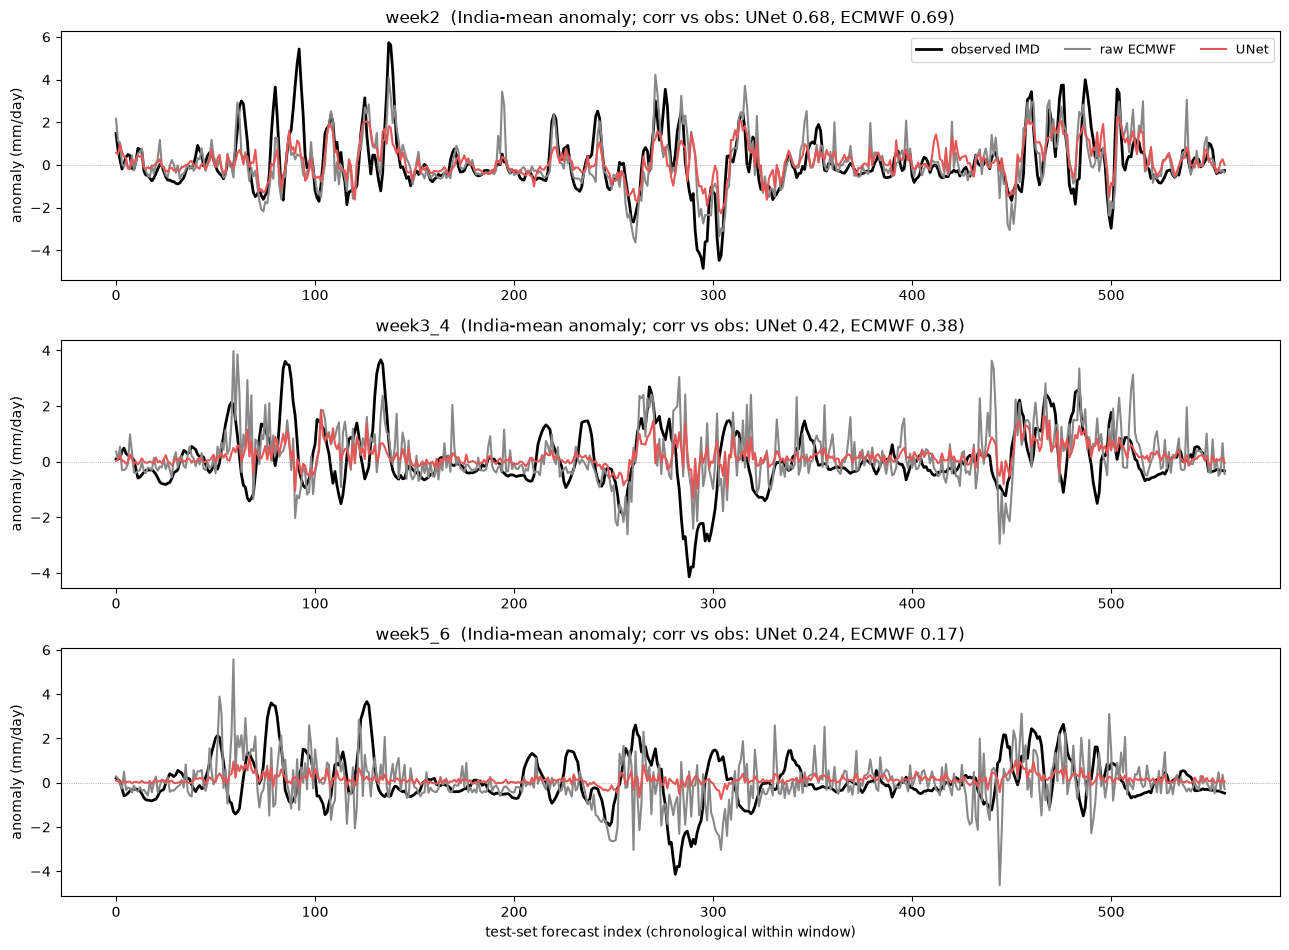

/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2339/912787939.py:61: RuntimeWarning: Mean of empty slice
  pm = np.nanmean(np.where(fin, p, np.nan), axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2339/912787939.py:62: RuntimeWarning: Mean of empty slice
  tm = np.nanmean(np.where(fin, t, np.nan), axis=0)
/Users/abhimanyu/Desktop/s2s/stsenv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


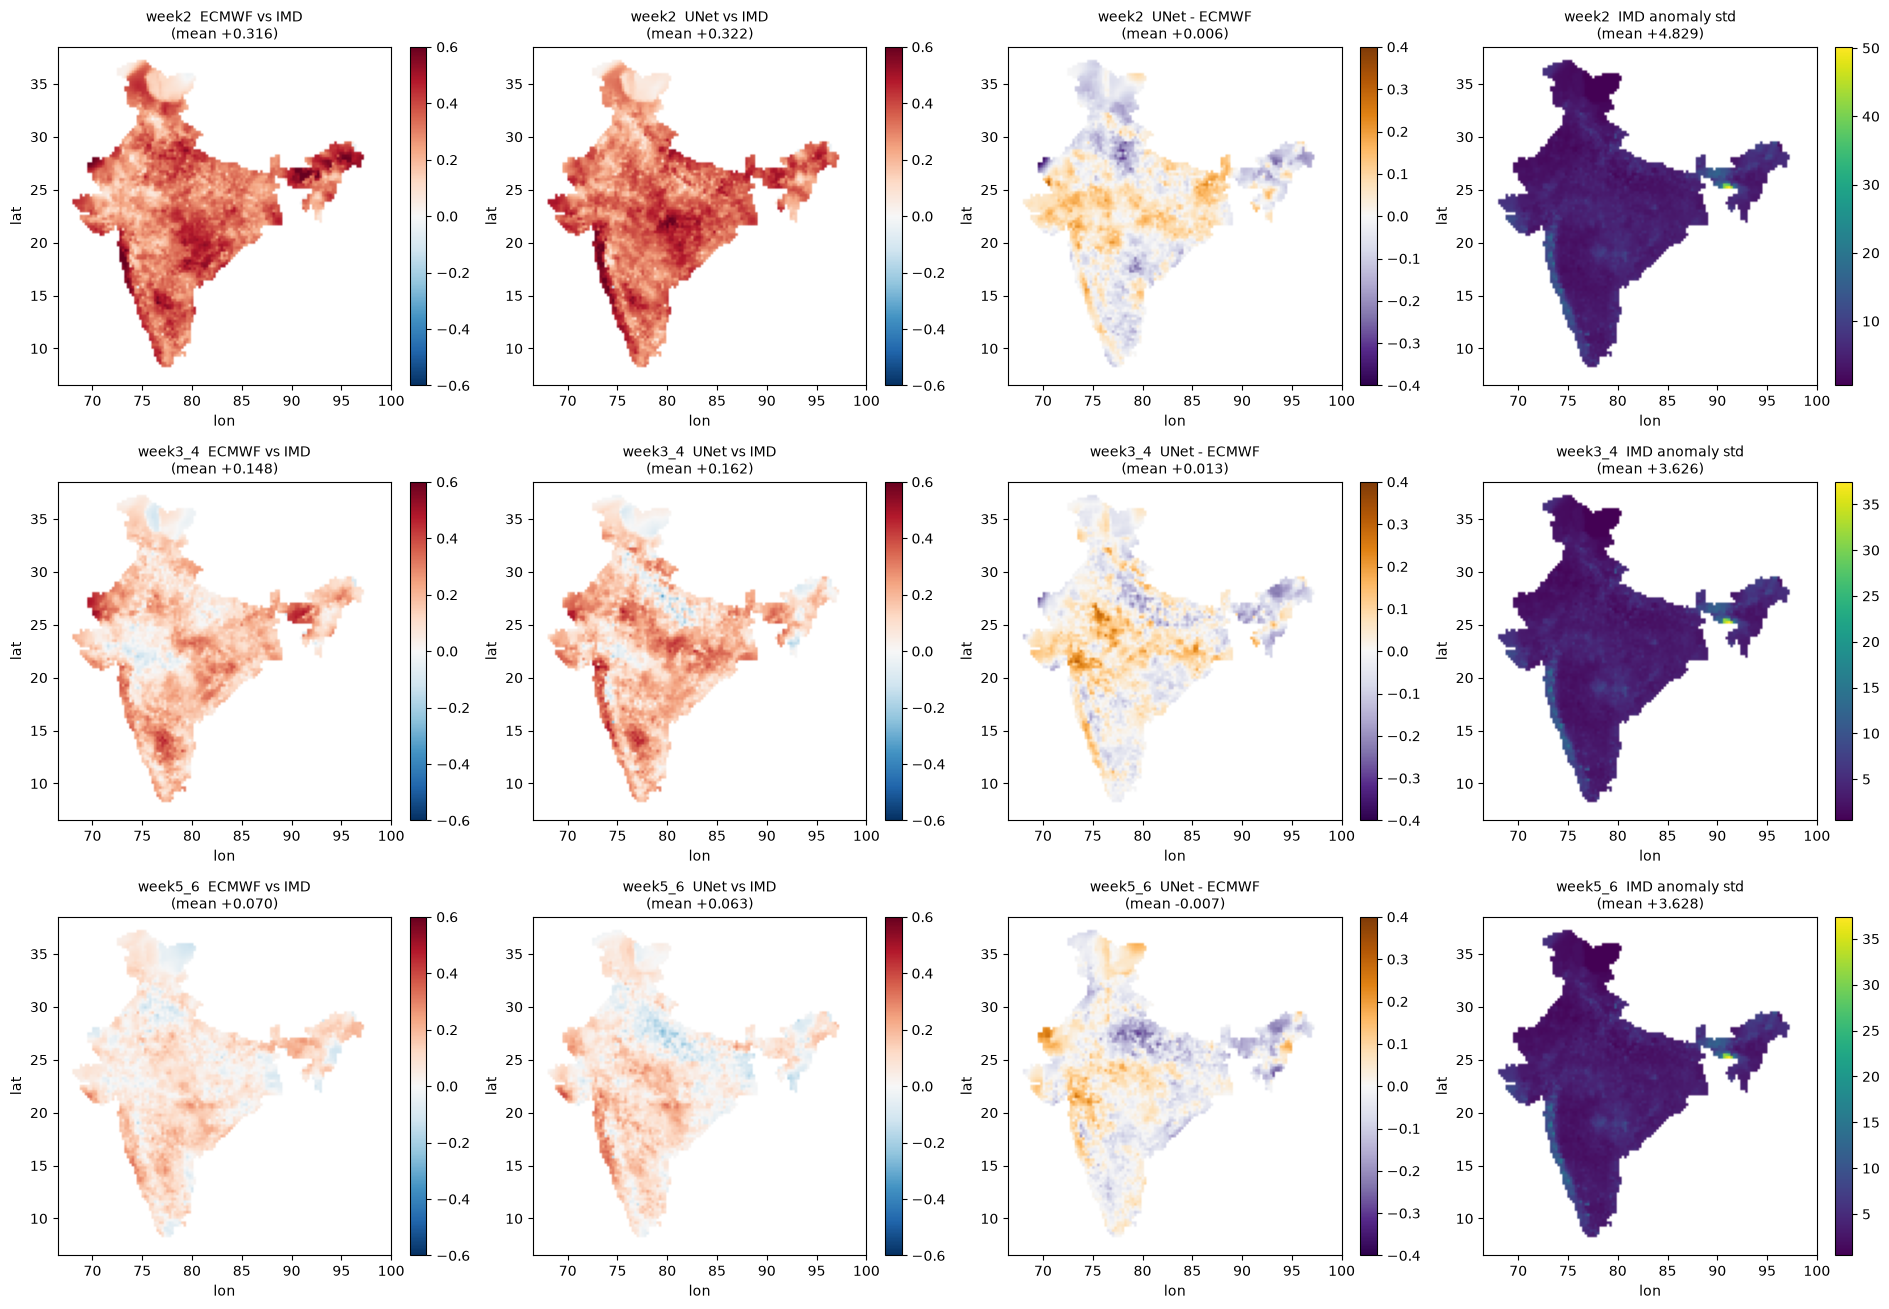


India-mean series correlation (threeline -- spatially averaged, higher):
    window    ECMWF     UNet
     week2    0.693    0.683
   week3_4    0.380    0.419
   week5_6    0.170    0.243

Per-cell correlation = ACC (maps -- the comparable metric):
    window    ECMWF     UNet  UNet better
     week2    0.316    0.322          54%
   week3_4    0.148    0.162          58%
   week5_6    0.070    0.063          47%

-> threeline_unet_mw_grad.png
-> corr_maps_unet_mw_grad.png / .nc / .npz
   corr_diff: orange = UNet better, purple = ECMWF better


In [19]:
# ======================================================================
# UNIFIED PLOTS from SAVED predictions -- Jupyter cell, no terminal needed.
#
# Reads the *_pred.npz your training run wrote, plus the cache, and makes:
#   threeline_<TAG>.png    India-mean anomaly series: IMD / ECMWF / UNet
#   corr_maps_<TAG>.png    per-cell corr maps: ECMWF | UNet | diff | obs std
#   corr_maps_<TAG>.nc     the maps as netcdf  (Panoply)
#   corr_maps_<TAG>.npz    the maps as arrays  (quick python reload)
#
# No model rebuild, no inference, no checkpoint. Just reads arrays.
#
# PREREQUISITE -- in the training script's final block, right after
#   p = predict(model, te_i, Xa)
# add:
#   np.savez_compressed(out_maps.replace(".nc", "_pred.npz"),
#                       pred=p, obs=t, wid=wid[is_test])
#
# TWO CORRELATIONS, DON'T CONFLATE:
#   threeline corr = correlation of the INDIA-MEAN series. Spatial averaging
#                    cancels per-cell noise, so it is systematically HIGHER
#                    (~0.45). Answers "is India as a whole wet or dry".
#   map corr       = per-cell correlation over time = ACC (~0.15). Answers
#                    "at this location, does the model track its ups/downs".
# IMD gets no corr panel -- it IS the truth. Panel 4 shows its anomaly std,
# so you can tell cheap skill (low-variance cells) from real skill.
# ======================================================================

import os
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# ---- CONFIG ----
PRED = "../results/models/unet_mw_grad_pred.npz"    # the *_pred.npz from training
CACHE = "../data/cache/unet_cache_mw.npz"
TAG = None                        # None -> inferred from PRED filename
CLIM_WINDOW_DAYS = 7
RAW_PRECIP_VAR = "total_precipitation"
DTYPE = np.float32

tag = TAG or os.path.basename(PRED).replace("_pred.npz", "")


def _clim(values, doys, window=CLIM_WINDOW_DAYS, n_doy=366):
    """DOY climatology via matmul. (n, ...) -> (366, ...), NaN-aware."""
    shp = values.shape[1:]
    v2 = values.reshape(len(values), -1)
    centers = np.arange(1, n_doy + 1)
    d = np.abs(doys[None, :].astype(int) - centers[:, None])
    M = (np.minimum(d, n_doy - d) <= window).astype(DTYPE)
    counts = M @ np.isfinite(v2).astype(DTYPE)
    sums = M @ np.nan_to_num(v2).astype(DTYPE)
    with np.errstate(invalid="ignore", divide="ignore"):
        c = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
    return c.reshape((n_doy,) + shp).astype(DTYPE)


def corr_map(p, t, fin):
    """Per-cell Pearson r over the sample axis. (n,H,W) -> (H,W)."""
    with np.errstate(invalid="ignore", divide="ignore"):
        pm = np.nanmean(np.where(fin, p, np.nan), axis=0)
        tm = np.nanmean(np.where(fin, t, np.nan), axis=0)
        num = np.nansum(np.where(fin, (p - pm) * (t - tm), np.nan), axis=0)
        den = np.sqrt(np.nansum(np.where(fin, (p - pm) ** 2, np.nan), axis=0)
                      * np.nansum(np.where(fin, (t - tm) ** 2, np.nan), axis=0))
        return np.where(den > 0, num / den, np.nan)


# ---- load saved predictions (test samples only) ----
pr = np.load(PRED, allow_pickle=False)
unet_a = pr["pred"].astype(DTYPE)        # (n_test, H, W) anomaly
obs_a = pr["obs"].astype(DTYPE)          # (n_test, H, W) anomaly
wid_te = pr["wid"]
print(f"loaded {PRED}: {unet_a.shape[0]} test samples")

# ---- cache: raw ECMWF, mask, coords ----
z = np.load(CACHE, allow_pickle=False)
X, y, doy, wid = z["X"], z["y"], z["doy"], z["wid"]
mask, is_test = z["mask"], z["is_test"]
clat, clon = z["clat"], z["clon"]
flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
feature_vars = [str(v) for v in z["feature_vars"]]
window_names = [str(w) for w in z["window_names"]]
n_win = len(window_names)

if unet_a.shape[0] != int(is_test.sum()):
    raise SystemExit(f"pred has {unet_a.shape[0]} samples but cache says "
                     f"{int(is_test.sum())} test samples -- mismatched files?")

fit_i = ~is_test
tp_idx = feature_vars.index(RAW_PRECIP_VAR)

# ---- raw ECMWF precip -> fine grid -> anomaly (its OWN climatology, so
#      the unit difference vs IMD cancels) ----
tp_fine = xr.DataArray(X[:, tp_idx], dims=("s", "lat", "lon"),
                       coords={"lat": clat, "lon": clon}
                       ).interp(lat=flat_lat, lon=flat_lon).values.astype(DTYPE)
ecm_clim = _clim(tp_fine[fit_i], doy[fit_i])[doy - 1]

# guard: a test doy with no train sample within +/-CLIM_WINDOW_DAYS gives a
# NaN climatology -> NaN anomaly -> NaN correlation, silently. Fires if
# MONTHS subsetting leaves season-edge gaps; harmless otherwise.
gap = np.isnan(ecm_clim[is_test]).mean()
if gap > 0.001:
    miss = sorted(set(doy[is_test].tolist()) - set(doy[fit_i].tolist()))
    print(f"    WARNING: {gap:.1%} of ECMWF climatology is NaN ({len(miss)} "
          f"test doys have no train sample within +/-{CLIM_WINDOW_DAYS}d) -> "
          f"ECMWF corr will be NaN there. Widen CLIM_WINDOW_DAYS.")
ecm_a = (tp_fine - ecm_clim)[is_test]

y_te = y[is_test]
m3 = mask[None]
fin_all = np.isfinite(y_te) & m3


# =============== 1. THREELINE ===============
def india_mean(a):
    return np.nansum(np.where(m3, a, np.nan), axis=(1, 2)) / m3.sum()

im_obs, im_ecm, im_unet = india_mean(obs_a), india_mean(ecm_a), india_mean(unet_a)

fig, axes = plt.subplots(n_win, 1, figsize=(13, 3.2 * n_win))
axes = np.atleast_1d(axes)
line_stats = []
for w in range(n_win):
    sel = wid_te == w
    ax = axes[w]
    t = np.arange(sel.sum())
    ax.plot(t, im_obs[sel], "-", color="black", lw=2, label="observed IMD")
    ax.plot(t, im_ecm[sel], "-", color="#888", lw=1.5, label="raw ECMWF")
    ax.plot(t, im_unet[sel], "-", color="#E45756", lw=1.5, label="UNet")
    ax.axhline(0, color="gray", lw=0.5, ls=":")
    ru = np.corrcoef(im_unet[sel], im_obs[sel])[0, 1]
    re = np.corrcoef(im_ecm[sel], im_obs[sel])[0, 1]
    line_stats.append((window_names[w], re, ru))
    ax.set_title(f"{window_names[w]}  (India-mean anomaly; "
                 f"corr vs obs: UNet {ru:.2f}, ECMWF {re:.2f})")
    ax.set_ylabel("anomaly (mm/day)")
    if w == 0:
        ax.legend(ncol=3, loc="upper right", fontsize=9)
axes[-1].set_xlabel("test-set forecast index (chronological within window)")
fig.tight_layout()
fig.savefig(f"../results/figures/threeline_{tag}.png", dpi=140)
plt.show()


# =============== 2. CORRELATION MAPS ===============
maps, map_stats = {}, []
for w in range(n_win):
    sel = wid_te == w
    fin = fin_all[sel]
    c_e = corr_map(ecm_a[sel], obs_a[sel], fin)
    c_u = corr_map(unet_a[sel], obs_a[sel], fin)
    o_sd = np.nanstd(np.where(fin, obs_a[sel], np.nan), axis=0)
    for arr in (c_e, c_u, o_sd):
        arr[~mask] = np.nan
    wn = window_names[w]
    maps[f"{wn}_corr_ecmwf"] = c_e
    maps[f"{wn}_corr_unet"] = c_u
    maps[f"{wn}_corr_diff"] = c_u - c_e
    maps[f"{wn}_obs_std"] = o_sd
    map_stats.append((wn, np.nanmean(c_e[mask]), np.nanmean(c_u[mask]),
                      100 * np.nanmean((c_u - c_e)[mask] > 0)))

# netcdf
ds = xr.Dataset({k: (("lat", "lon"), v) for k, v in maps.items()},
                coords={"lat": flat_lat, "lon": flat_lon})
ds.attrs["source"] = PRED
ds.attrs["note"] = ("per-cell anomaly correlation over test forecasts (= ACC); "
                    "corr_diff = unet - ecmwf, >0 means UNet better")
ds.to_netcdf(f"../results/models/corr_maps_{tag}.nc")

# npz (same data, second format)
np.savez_compressed(f"../results/models/corr_maps_{tag}.npz", lat=flat_lat, lon=flat_lon,
                    mask=mask, window_names=np.array(window_names), **maps)

fig, axes = plt.subplots(n_win, 4, figsize=(19, 4.4 * n_win))
axes = np.atleast_2d(axes)
ext = [flat_lon[0], flat_lon[-1], flat_lat[0], flat_lat[-1]]
for w in range(n_win):
    wn = window_names[w]
    panels = [(f"{wn}_corr_ecmwf", "ECMWF vs IMD", "RdBu_r", -0.6, 0.6),
              (f"{wn}_corr_unet", "UNet vs IMD", "RdBu_r", -0.6, 0.6),
              (f"{wn}_corr_diff", "UNet - ECMWF", "PuOr_r", -0.4, 0.4),
              (f"{wn}_obs_std", "IMD anomaly std", "viridis", None, None)]
    for c, (key, title, cmap, vmin, vmax) in enumerate(panels):
        ax = axes[w, c]
        arr = maps[key]
        kw = dict(cmap=cmap, origin="lower", extent=ext, aspect="auto")
        if vmin is not None:
            kw.update(vmin=vmin, vmax=vmax)
        im = ax.imshow(arr, **kw)
        fig.colorbar(im, ax=ax, fraction=0.046)
        ax.set_title(f"{wn}  {title}\n(mean {np.nanmean(arr[mask]):+.3f})",
                     fontsize=10)
        ax.set_xlabel("lon"); ax.set_ylabel("lat")
fig.tight_layout()
fig.savefig(f"../results/figures/corr_maps_{tag}.png", dpi=130)
plt.show()


# =============== SUMMARY ===============
print("\nIndia-mean series correlation (threeline -- spatially averaged, higher):")
print(f"{'window':>10} {'ECMWF':>8} {'UNet':>8}")
for wn, re, ru in line_stats:
    print(f"{wn:>10} {re:>8.3f} {ru:>8.3f}")

print("\nPer-cell correlation = ACC (maps -- the comparable metric):")
print(f"{'window':>10} {'ECMWF':>8} {'UNet':>8} {'UNet better':>12}")
for wn, ce, cu, pct in map_stats:
    print(f"{wn:>10} {ce:>8.3f} {cu:>8.3f} {pct:>11.0f}%")

print(f"\n-> threeline_{tag}.png")
print(f"-> corr_maps_{tag}.png / .nc / .npz")
print("   corr_diff: orange = UNet better, purple = ECMWF better")

In [20]:
import xarray as xr
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Select the variable you want to compare
# (Change these variable names to match what's in your datasets)
# ---------------------------------------------------------
imd_var = imd_ds['rain']                 # Example IMD variable
ecmwf_var = ecmwf_ds['total_precipitation'] # Example ECMWF variable

# ---------------------------------------------------------
# 2. Align the data 
# ECMWF has a 'step' (lead time) dimension. Let's select day 1 (step=24).
# We also use xarray's interp_like to make sure the grids match perfectly.
# ---------------------------------------------------------
# Select a specific lead time (e.g., 24 hours) from ECMWF
ecmwf_slice = ecmwf_var.sel(step=24) 

# Ensure IMD data is on the exact same lat/lon grid as ECMWF
imd_aligned = imd_var.interp_like(ecmwf_slice, method='nearest')

# ---------------------------------------------------------
# 3. Calculate Residual
# ---------------------------------------------------------
residual = imd_aligned - ecmwf_slice
residual.name = "Residual (IMD - ECMWF)"

# ---------------------------------------------------------
# 4. Plot the Residual
# (Selecting the first time step just to get a 2D map)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# RdBu_r is a great colormap for residuals (Red=Negative, Blue=Positive)
residual.isel(time=0).plot(
    cmap="RdBu", 
    robust=True, # robust=True hides extreme outliers in the colorbar
    cbar_kwargs={'label': 'Difference (IMD - ECMWF)'}
)

plt.title("Residual Map: IMD vs ECMWF (First Time Step)")
plt.tight_layout()
plt.show()


NameError: name 'imd_ds' is not defined